<a href="https://colab.research.google.com/github/Rijalpratama23/PengolahanCitraDigital/blob/main/praktik10_RijalPratama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

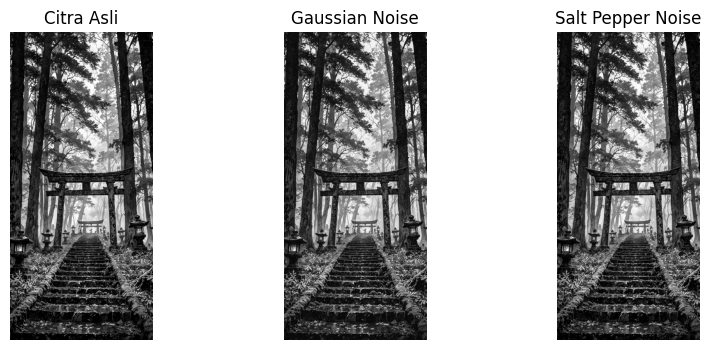

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. MEMBACA GAMBAR
# Sesuaikan path file di bawah dengan lokasi gambar di laptop Anda
img = cv2.imread("poto.jpg", cv2.IMREAD_GRAYSCALE)

# 2. GAUSSIAN NOISE
# Menambahkan noise normal distribution
# Source code asli ada typo, gini versi yang sudah diperbaiki agar jalan:
gaussian = img + np.random.normal(0, 25, img.shape)
gaussian = np.clip(gaussian, 0, 255).astype("uint8")

# 3. SALT & PEPPER NOISE
saltpep = img.copy()
prob = 0.02
# Memperbaiki typo "img.shape" pada modul menjadi *img.shape
rnd = np.random.rand(*img.shape)

# Menambahkan titik hitam (Pepper)
saltpep[rnd < prob/2] = 0
# Menambahkan titik putih (Salt)
saltpep[rnd > 1 - prob/2] = 255

# TAMPILKAN HASIL NOISE
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title("Citra Asli"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(gaussian, cmap='gray'); plt.title("Gaussian Noise"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(saltpep, cmap='gray'); plt.title("Salt Pepper Noise"); plt.axis('off')
plt.show()


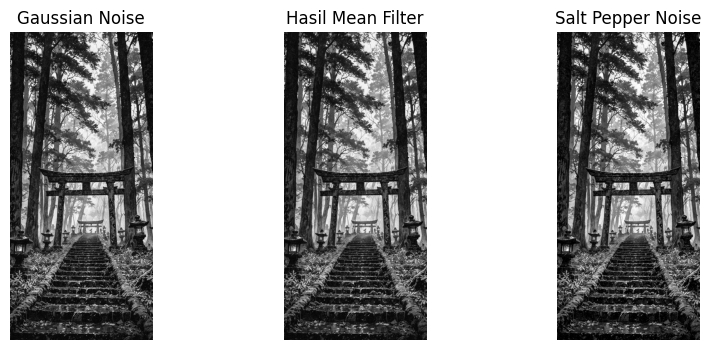

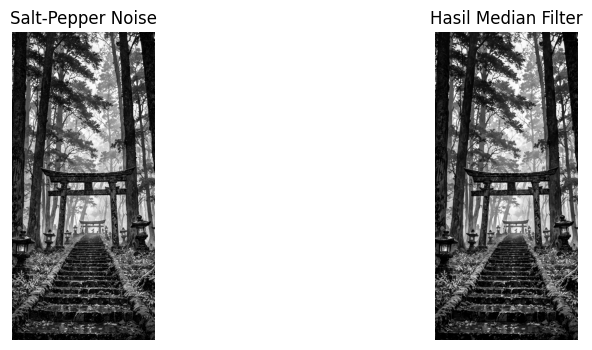

In [2]:
# FILTER MEAN (digunakan untuk mereduksi Gaussian Noise)
mean = cv2.blur(gaussian, (3,3))

# FILTER MEDIAN (digunakan untuk mereduksi Salt-Pepper Noise)
median = cv2.medianBlur(saltpep, 3)

# TAMPILKAN HASIL RESTORASI GAUSSIAN (Mean Filter)
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(gaussian, cmap='gray'); plt.title("Gaussian Noise"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(mean, cmap='gray'); plt.title("Hasil Mean Filter"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(saltpep, cmap='gray'); plt.title("Salt Pepper Noise"); plt.axis('off')
plt.show()

# TAMPILKAN HASIL RESTORASI SALT-PEPPER (Median Filter)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(saltpep, cmap='gray'); plt.title("Salt-Pepper Noise"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(median, cmap='gray'); plt.title("Hasil Median Filter"); plt.axis('off')
plt.show()


In [5]:

# ===== PSNR Evaluation =====
def PSNR(original, restored):
    # Menghitung MSE (Mean Squared Error)
    mse = np.mean((original - restored) ** 2)
    if mse == 0: # Jika tidak ada perbedaan sama sekali
        return 100
    max_pixel = 255.0
    # Rumus PSNR
    return 20 * np.log10(max_pixel / np.sqrt(mse))

# Menghitung PSNR untuk kedua hasil filter
psnr_mean = PSNR(img, mean)
psnr_median = PSNR(img, median)

# Menampilkan hasil di terminal
print("=== Evaluasi PSNR ===")
print(f"PSNR hasil Mean Filter   : {psnr_mean:.2f} dB")
print(f"PSNR hasil Median Filter : {psnr_median:.2f} dB")

=== Evaluasi PSNR ===
PSNR hasil Mean Filter   : 29.53 dB
PSNR hasil Median Filter : 32.91 dB
